Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


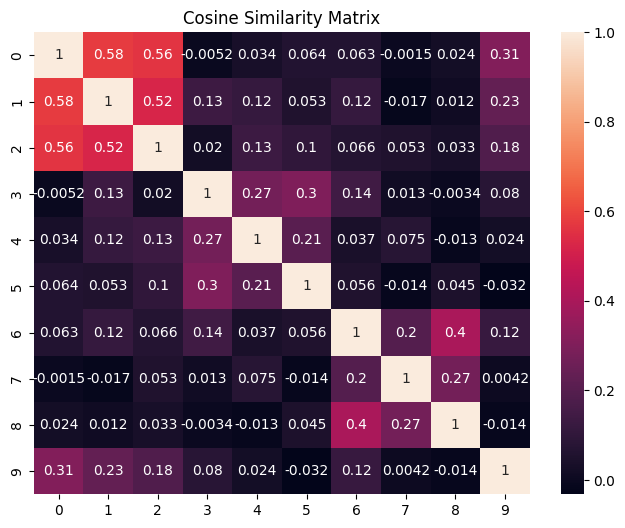

Top 2 similar sentences:
The bowler took a wicket in the last over -> Score: 0.8586698
The batsman scored a century in the match -> Score: 0.56821966


In [ ]:
# Install library
!pip install sentence-transformers

# Import
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 10 sentences (3 topics)
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took a wicket in the last over",
    "The team won the cricket tournament",

    # Cooking
    "I cooked pasta for dinner",
    "She baked a delicious chocolate cake",
    "Cooking requires patience and skill",

    # Cybersecurity
    "Hackers attacked the system",
    "Data encryption protects sensitive information",
    "Cybersecurity is important for businesses",

    # Extra
    "The player hit a six in the stadium"
]

# Create embeddings
embeddings = model.encode(sentences)

# Cosine similarity
similarity_matrix = cosine_similarity(embeddings, embeddings)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True)
plt.title("Cosine Similarity Matrix")
plt.show()

# Query
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Compare similarity
scores = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2
top_indices = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], "-> Score:", scores[i])